In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Load the data as a pandas DataFrame
housing_data = fetch_california_housing(as_frame=True)
df = pd.concat([housing_data.data, housing_data.target.rename('MedHouseVal')], axis=1)

# Look at the first 5 rows of data
df.head()

Matplotlib is building the font cache; this may take a moment.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


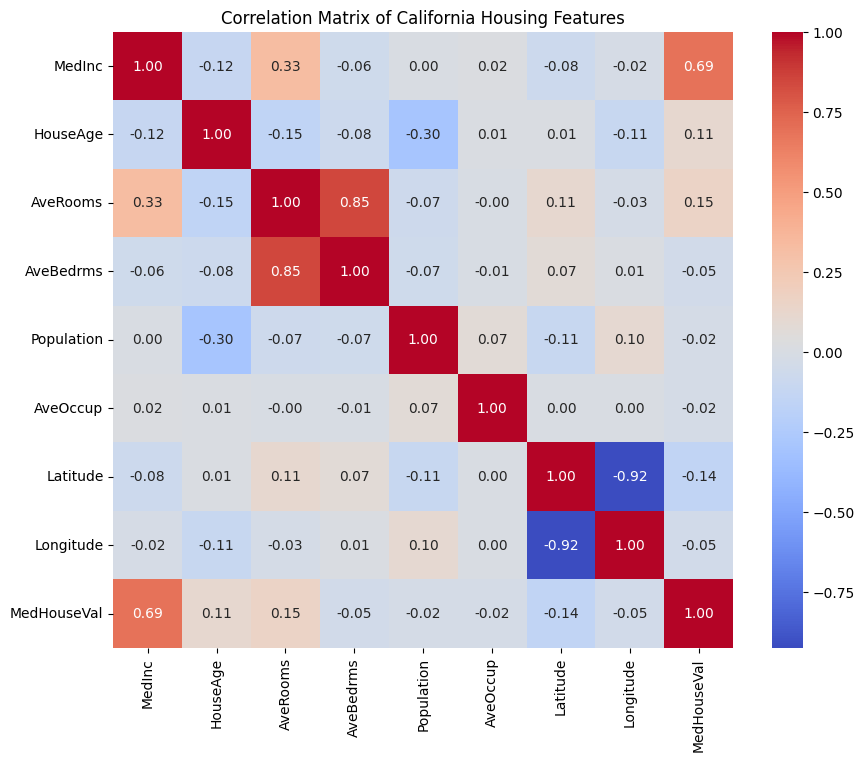

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Load data
housing_data = fetch_california_housing(as_frame=True)
df = pd.concat([housing_data.data, housing_data.target.rename('MedHouseVal')], axis=1)

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of California Housing Features")

# ADDED LINE: This automatically saves the image to your folder
plt.savefig('housing_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Split features (X) from target prices (y)
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

# Calculate performance metrics using the new function
from sklearn.metrics import root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error (MAE): 0.533
Root Mean Squared Error (RMSE): 0.746
R² Score: 0.576


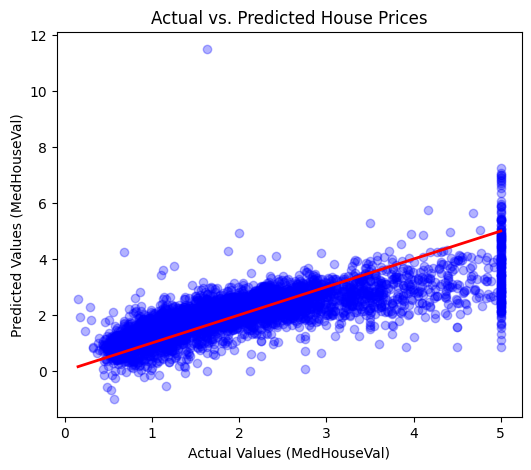

In [6]:
import matplotlib.pyplot as plt

# Create the scatter plot size
plt.figure(figsize=(6, 5))

# Plot the actual vs predicted data points
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')

# Draw the red line of perfect fit
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)

# Label the axes and title
plt.xlabel("Actual Values (MedHouseVal)")
plt.ylabel("Predicted Values (MedHouseVal)")
plt.title("Actual vs. Predicted House Prices")

# ADDED LINE: This automatically saves the image as a file to your folder
plt.savefig('actual_vs_predicted_chart.png', dpi=300, bbox_inches='tight')

# Display the chart on your screen
plt.show()